Esse notebook tem o objetivo de visualizar as porosidades ao longo dos poços escolhidos que fazem parte da "Área Teste 1" como definido no notebook "wells_viz". Além disso, deve gerar o arquivo com os dados de porosidade para servirem de entrada para o pipeline do algoritmo.

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import pandas as pd
import pathlib

# Carregando dados gerais dos poços

In [3]:
all_wells_info_path = pathlib.Path("wells_info_completed.csv")
all_wells_info = pd.read_csv(all_wells_info_path)
all_wells_info.head()

,Well,x_coord,y_coord,min_y,max_y,type,min_y_adjusted,max_y_adjusted,test_area
0,2-ANP-1-RJS,677,1722,5400,5880,bottom,1080,1176,NaN
1,3-BRSA-1064-RJS,652,1114,5000,5930,bottom,1000,1186,NaN
2,3-BRSA-1184-RJS,855,1230,5400,5900,bottom,1080,1180,1.0
3,3-BRSA-1195-RJS,1041,2322,5450,5900,bottom,1090,1180,NaN
4,7-BUZ-10-RJS,415,392,5300,5780,bottom,1060,1156,3.0


In [4]:
area1_wells_info = all_wells_info.query("test_area == 1")
area1_wells_info

,Well,x_coord,y_coord,min_y,max_y,type,min_y_adjusted,max_y_adjusted,test_area
2,3-BRSA-1184-RJS,855,1230,5400,5900,bottom,1080,1180,1.0
5,7-BUZ-12-RJS,834,1297,2118,5873,complete,423,1174,1.0
13,7-BUZ-30-RJS,833,1384,5300,5900,bottom,1060,1180,1.0
18,8-BUZ-21D-RJS,898,1246,2099,5978,complete,419,1195,1.0
24,8-BUZ-32D-RJS,901,1332,2079,3368,top,415,673,1.0
25,8-BUZ-32DA-RJS,901,1332,2858,6056,complete,571,1211,1.0


Como informado, não foi possível conseguir os valores de porosidade para o poço 8-BUZ-32D-RJS. Pode-se perceber que, na verdade, ele possui as mesmas coordenadas que o poço 8-BUZ-32DA-RJS. De acordo com o informado, diferentes medições ao longo do mesmo poço são comuns. Por sorte, o 8-BUZ-32DA-RJS é o que possui maior range de medições. Além disso, ambos possuem indicações de medições entre min_y=2858 e max_y=3368. Assim, não "perdemos" completamente as medições do 8-BUZ-32D-RJS.

In [5]:
area1_wells_info = area1_wells_info[area1_wells_info['Well'] != '8-BUZ-32D-RJS']
area1_wells_info

,Well,x_coord,y_coord,min_y,max_y,type,min_y_adjusted,max_y_adjusted,test_area
2,3-BRSA-1184-RJS,855,1230,5400,5900,bottom,1080,1180,1.0
5,7-BUZ-12-RJS,834,1297,2118,5873,complete,423,1174,1.0
13,7-BUZ-30-RJS,833,1384,5300,5900,bottom,1060,1180,1.0
18,8-BUZ-21D-RJS,898,1246,2099,5978,complete,419,1195,1.0
25,8-BUZ-32DA-RJS,901,1332,2858,6056,complete,571,1211,1.0


# Carregando porosidade dos poços

In [6]:
wells_porosity_folder = pathlib.Path("../../../../../../data/ANP/raw/wells_porosity/")
all_porosities = wells_porosity_folder.glob("*")
target_wells_names = set(area1_wells_info['Well'].tolist())
print(target_wells_names)
target_files = dict()
for porosity_file in all_porosities:
    well_name = porosity_file.stem 
    if well_name in target_wells_names:
        target_files[well_name] = porosity_file.resolve()

{'8-BUZ-21D-RJS', '3-BRSA-1184-RJS', '8-BUZ-32DA-RJS', '7-BUZ-12-RJS', '7-BUZ-30-RJS'}


In [7]:
target_files

{'8-BUZ-32DA-RJS': PosixPath('/home/daniel/Documentos/Git/petroiageo/data/ANP/raw/wells_porosity/8-BUZ-32DA-RJS.txt'),
 '8-BUZ-21D-RJS': PosixPath('/home/daniel/Documentos/Git/petroiageo/data/ANP/raw/wells_porosity/8-BUZ-21D-RJS.txt'),
 '7-BUZ-12-RJS': PosixPath('/home/daniel/Documentos/Git/petroiageo/data/ANP/raw/wells_porosity/7-BUZ-12-RJS.txt'),
 '3-BRSA-1184-RJS': PosixPath('/home/daniel/Documentos/Git/petroiageo/data/ANP/raw/wells_porosity/3-BRSA-1184-RJS.txt'),
 '7-BUZ-30-RJS': PosixPath('/home/daniel/Documentos/Git/petroiageo/data/ANP/raw/wells_porosity/7-BUZ-30-RJS.txt')}

In [8]:
porosity_dfs_dict = dict()
column_names = ['depth', 'neutron_por', 'density_por', 'sonic_por']
for well_name, por_path in target_files.items():
    por_df = pd.read_csv(por_path, sep=' ', header=None, names=column_names)
    porosity_dfs_dict[well_name] = por_df

In [9]:
porosity_dfs_dict['8-BUZ-32DA-RJS'].head()

,depth,neutron_por,density_por,sonic_por
0,5651.4200,16.8925,22.703297,17.283618
1,5651.5724,16.5314,22.445055,17.387566
2,5651.7248,16.2757,23.181319,17.430987
3,5651.8772,16.4892,23.758242,17.442303
4,5652.0296,15.8871,23.708791,17.354803


# Analisando as porosidades

## Comparando os ranges esperados com os obtidos

In [10]:
for well_name, por_df in porosity_dfs_dict.items():
    well_info = area1_wells_info.query('Well == @well_name')
    range = well_info['max_y'].values[0] - well_info['min_y'].values[0]
    print(f"{well_name}. QT de medições: {len(por_df)}. Range esperado: {range}")

8-BUZ-32DA-RJS. QT de medições: 2490. Range esperado: 3198
8-BUZ-21D-RJS. QT de medições: 2760. Range esperado: 3879
7-BUZ-12-RJS. QT de medições: 3494. Range esperado: 3755
3-BRSA-1184-RJS. QT de medições: 2267. Range esperado: 500
7-BUZ-30-RJS. QT de medições: 2352. Range esperado: 600


Alguns poços parecem possuir menos medições do que o esperado. Além disso, deve ser necessário realizar uma interpolação dos valores de porosidade para que o valor de 'depth' seja mais discretizado.

In [11]:
real_and_expected_range_for_well = dict()
for well_name, por_df in porosity_dfs_dict.items():
    well_info = area1_wells_info.query('Well == @well_name')
    expected_range = (well_info['min_y'].values[0], well_info['max_y'].values[0])
    real_range = (por_df['depth'].min(), por_df['depth'].max())
    ranges = (real_range, expected_range)
    real_and_expected_range_for_well[well_name] = ranges

In [12]:
real_and_expected_range_for_well

{'8-BUZ-32DA-RJS': ((5651.42, 6030.7436), (2858, 6056)),
 '8-BUZ-21D-RJS': ((5517.4268, 5937.8984), (2099, 5978)),
 '7-BUZ-12-RJS': ((5331.4141, 5863.7473), (2118, 5873)),
 '3-BRSA-1184-RJS': ((5420.0, 5873.2), (5400, 5900)),
 '7-BUZ-30-RJS': ((5339.8, 5810.0), (5300, 5900))}

In [13]:
def plot_range(min_y, max_y, x, color='blue', label=None):
    if label == None:
        plt.vlines(x, min_y, max_y, colors=color, lw=4, zorder=3)
    else:
        plt.vlines(x, min_y, max_y, colors=color, label=label, lw=4, zorder=3)
        
    plt.hlines(min_y, x+0.3, x-0.3, color, lw=2, zorder=3)
    plt.hlines(max_y, x+0.3, x-0.3, color, lw=2, zorder=3)

In [14]:
import numpy as np

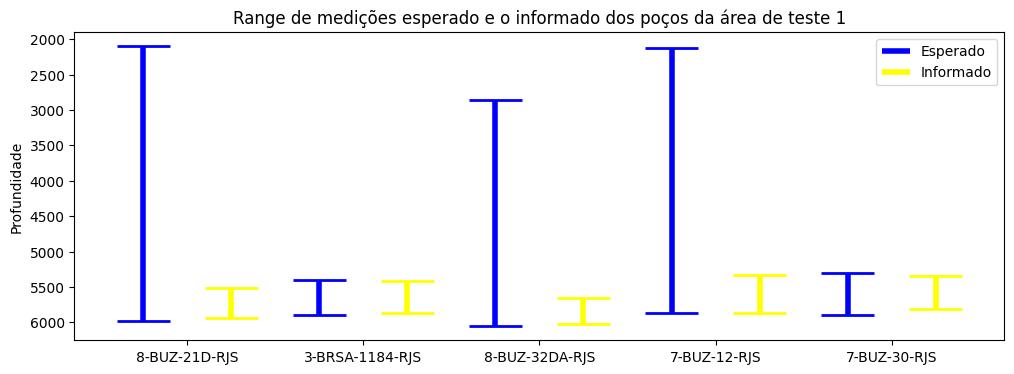

In [15]:
fig = plt.figure(figsize=(12,4))

color_dict = {'expected': 'blue', 'real':'yellow'}

curr_x = 1
for well_idx, well in enumerate(target_wells_names):
    real_range, expected_range = real_and_expected_range_for_well[well]
    label = True
    expected_label = "Esperado"
    real_label = "Informado"
    if well_idx > 0:
        label = False
        expected_label = None
        real_label = None
    
    plot_range(expected_range[0], expected_range[1], curr_x, color_dict['expected'], expected_label)
    plot_range(real_range[0], real_range[1], curr_x+1, color_dict['real'], real_label)
    curr_x += 2

plt.gca().invert_yaxis()
plt.ylabel('Profundidade')
plt.title("Range de medições esperado e o informado dos poços da área de teste 1")
plt.legend()
num_wells = len(target_wells_names)
plt.xticks(np.arange(1.5, 2*num_wells, 2), labels=list(target_wells_names))
plt.savefig(f"range_esperado_e_informado_pocos_area1.png")
plt.show() 

# Definindo o range alvo para todos os poços

Precisamos de um range em z comum para todos os poços. Ele deverá estar entre o máximo primeiro z e mínimo último z dentre os ranges dos poços.

In [16]:
first_z = max([real[0] for real, _ in real_and_expected_range_for_well.values()])
last_z = min([real[1] for real, _ in real_and_expected_range_for_well.values()])
first_z, last_z

(5651.42, 5810.0)

Cerca de 160 metros.

# Agregando medições

Existe mais de uma medição ao longo do mesmo metro no eixo z para os poços. Precisamos transformar essas várias medições em uma só para o metro correspondente. As medições dentro de um mesmo metro serão agregadas usando a média. Como haverá a agregação dentro de um mesmo metro, vou também alterar os ranges para serem inteiros:

In [17]:
first_z, last_z = int(first_z), int(last_z)

In [18]:
for well_por_df in porosity_dfs_dict.values():
    well_por_df['depth_m'] = well_por_df['depth'].apply(lambda x: int(str(x).split('.')[0])) 

In [19]:
porosity_dfs_dict['8-BUZ-32DA-RJS'].head()

,depth,neutron_por,density_por,sonic_por,depth_m
0,5651.4200,16.8925,22.703297,17.283618,5651
1,5651.5724,16.5314,22.445055,17.387566,5651
2,5651.7248,16.2757,23.181319,17.430987,5651
3,5651.8772,16.4892,23.758242,17.442303,5651
4,5652.0296,15.8871,23.708791,17.354803,5652


Agora cada linha possui o metro associado. Vamos agrupar e gerar novos dfs.

In [20]:
agg_por_dfs_dict = dict()
for well_name, well_por_df in porosity_dfs_dict.items():
    grouped = well_por_df.groupby(by='depth_m').mean()
    agg_por_dfs_dict[well_name] = grouped.add_suffix("_mean").reset_index()
    agg_por_dfs_dict[well_name].drop('depth_mean', inplace=True, axis=1)

In [21]:
agg_por_dfs_dict['8-BUZ-32DA-RJS'].head()

,depth_m,neutron_por_mean,density_por_mean,sonic_por_mean
0,5651,16.547200,23.021978,17.386118
1,5652,15.421700,22.468603,16.017397
2,5653,8.760350,13.090659,10.855559
3,5654,8.247543,11.029827,10.812265
4,5655,12.490986,19.972527,14.511974


Temos o valor médio de porosidade dentro de cada unidade de metro. Agora vamos filtrar os dados apenas no range em z alvo.

In [22]:
for well_name, well_agg_df in agg_por_dfs_dict.items():
    filtered = well_agg_df.query('depth_m >= @first_z and depth_m <= @last_z')
    agg_por_dfs_dict[well_name] = filtered

In [23]:
agg_por_dfs_dict['8-BUZ-32DA-RJS'].head()

,depth_m,neutron_por_mean,density_por_mean,sonic_por_mean
0,5651,16.547200,23.021978,17.386118
1,5652,15.421700,22.468603,16.017397
2,5653,8.760350,13.090659,10.855559
3,5654,8.247543,11.029827,10.812265
4,5655,12.490986,19.972527,14.511974


O arquivo de medições sísmicas da área total possui medições em intervalos de 5 metros no eixo z. Dessa forma, devo filtrar apenas as profundidades que sejam múltiplas de 5.

In [25]:
for well_name, well_df in agg_por_dfs_dict.items():
    filtered_df = well_df.query('depth_m%5==0')
    agg_por_dfs_dict[well_name] = filtered_df

Vamos checar a quantidade de medidas que sobraram por poço:

In [26]:
for well_name, well_agg_df in agg_por_dfs_dict.items():
    min_z = well_agg_df['depth_m'].min()
    max_z = well_agg_df['depth_m'].max()
    n_medicoes = len(well_agg_df)
    print(f"{well_name}: min_z={min_z}, max_z={max_z}, medições: {n_medicoes}")

8-BUZ-32DA-RJS: min_z=5655, max_z=5810, medições: 32
8-BUZ-21D-RJS: min_z=5655, max_z=5810, medições: 32
7-BUZ-12-RJS: min_z=5655, max_z=5810, medições: 32
3-BRSA-1184-RJS: min_z=5655, max_z=5810, medições: 32
7-BUZ-30-RJS: min_z=5655, max_z=5810, medições: 32


Todos possuem 32 medições dentro do mesmo range.

## Visualizando as porosidades dos poços

In [27]:
def _unify_dfs(wells_porosity_df_dict, target_porosity):
    unified_df = pd.DataFrame()
    well_names_list = list()
    for well_name, well_df in wells_porosity_df_dict.items():
        # unique_wells_names.append(well_name)
        num_meds = len(well_df)
        well_names_list.extend([well_name]*num_meds)
        unified_df = pd.concat([unified_df, well_df[['depth_m',target_porosity]]])

    unified_df['Well'] = well_names_list
    unified_df.reset_index(inplace=True)
    return unified_df
    
def plot_divided_wells_porosity(wells_porosity_df_dict, target_porosity, 
                                por_title_name, save=False, save_path=None):

    unified_df = _unify_dfs(wells_porosity_df_dict, target_porosity)
    
    mean_porsty = unified_df[target_porosity].mean()
    unified_df[target_porosity] -= mean_porsty

    #update porosities for ploting purposes
    distance = mean_porsty+10
    dist_acc = 0
    new_porsties = list()
    unique_wells_names = list(wells_porosity_df_dict.keys())
    for well_name in unique_wells_names:
        curr_pors = unified_df.query('Well == @well_name')[target_porosity] 
        new_pors = curr_pors + dist_acc
        new_porsties.extend(new_pors.tolist())
        dist_acc += distance
        
    unified_df[target_porosity] = new_porsties
        
    plt.figure(figsize=(10, 6))
    sns.lineplot(unified_df, x=target_porosity, y='depth_m', 
                 hue='Well', orient='y')
    wells_x_ticks = np.arange(0, dist_acc, distance)
    plt.xticks(wells_x_ticks, labels=unique_wells_names)
    
    min_depth = unified_df['depth_m'].min()
    max_depth = unified_df['depth_m'].max()
    for xtick in wells_x_ticks:
        plt.vlines(xtick, min_depth, max_depth, colors='grey', linestyles ="dashed", zorder=3)
    
    plt.xlim(-mean_porsty-5, wells_x_ticks.max()+50)
    plt.xlabel("Well")
    title_fmt = "Movimento da porosidade ({}) dos poços com relação à media ({:.5})"
    plt.title(title_fmt.format(por_title_name, mean_porsty))
    plt.gca().invert_yaxis()
    if save:
        plt.savefig(save_path)
    plt.show()

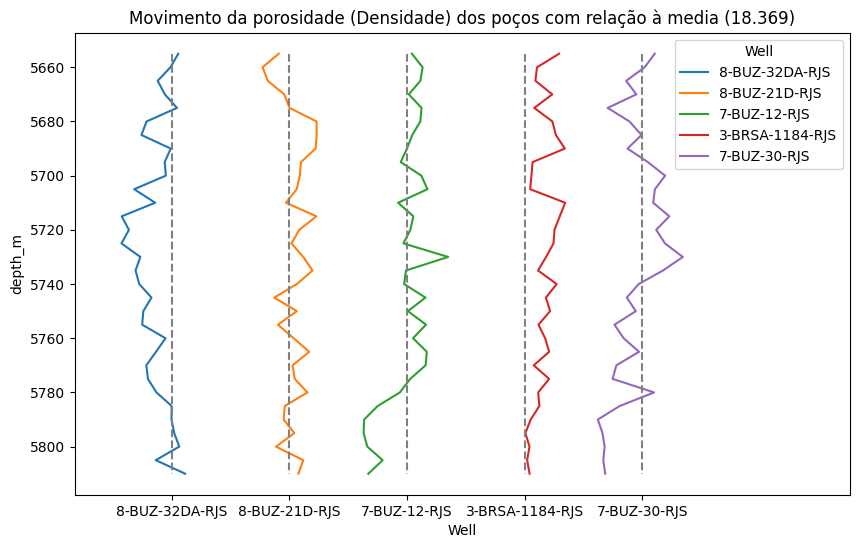

In [28]:
save_path = "porosidade_area_1.png"
save = True
plot_divided_wells_porosity(agg_por_dfs_dict, 'density_por_mean', 'Densidade', save, save_path)

# Gerando o dado final

Agora, vou unir os dados em apenas um arquivo. Esse arquivo será específico para uma porosidade de escolha. Além disso, ele estará pronto para passar pelo pipeline do algoritmo. As coordenadas x e y dos poços também estarão relativas à área teste.

## Carregando os dados das áreas

In [29]:
areas_coords_path = pathlib.Path('areas_coords.csv')
areas_df = pd.read_csv(areas_coords_path)
areas_df

,max_x,min_x,min_y,max_y,area
0,925,800,1200,1450,1
1,750,600,1300,1600,2
2,550,350,150,550,3


In [30]:
area_1_coords = areas_df.query('area == 1')
min_y_area = area_1_coords['min_y'][0]
min_x_area = area_1_coords['min_x'][0]
min_x_area, min_y_area

(800, 1200)

## Gerando o arquivo final

In [31]:
target_por = 'density_por_mean'
target_df = pd.DataFrame()
for row_idx, row in area1_wells_info.iterrows():
    well_name = row['Well']
    x_coord = row['x_coord']
    y_coord = row['y_coord']
    agg_por_df = agg_por_dfs_dict[well_name]
    num_meds = len(agg_por_df)
    curr_df = pd.DataFrame()
    curr_df['x'] = [x_coord-min_x_area]*num_meds
    curr_df['y'] = [y_coord-min_y_area]*num_meds
    curr_df['z'] = agg_por_df['depth_m'].tolist()
    curr_df['phi'] = agg_por_df[target_por].tolist()
    target_df = pd.concat([target_df, curr_df])

In [32]:
target_df.reset_index(inplace=True)
target_df.drop('index', axis=1, inplace=True)
target_df

,x,y,z,phi
0,55,30,5655,26.683516
1,55,30,5660,21.352747
2,55,30,5665,20.974725
3,55,30,5670,25.047253
4,55,30,5675,20.696703
...,...,...,...,...
155,101,132,5790,18.339744
156,101,132,5795,18.999084
157,101,132,5800,20.215071
158,101,132,5805,14.545526


In [33]:
target_npy_file_path = pathlib.Path('../../../../../../data/ANP/processed/area_1_porsty.npy')
np.save(target_npy_file_path, target_df.to_numpy())

In [34]:
my_np_array = np.load(target_npy_file_path)

In [35]:
my_np_array.dtype

dtype('float64')